In [17]:
from itertools import combinations_with_replacement

x = [0, 1]
masses = [1, 2]

combination_edges = [
    [[A, B], [C]] for A, B in combinations_with_replacement(x, 2)
    for C in x
    if masses[A] + masses[B] == masses[C]
]
print(list(combinations_with_replacement(x, 2)))

[(0, 0), (0, 1), (1, 1)]


In [21]:
import pandas as pd
import json
n = 0
df1 = pd.read_csv("../../datasets/WDN/full_set_1.csv")
for row in df1.head(1000)['reactions']:
    n += len(json.loads(row))

print(n)

11626


In [ ]:
import pandas as pd
import numpy as np

df = pd.read_csv("../../datasets/WDN/simple_transformation_set_2/simple_transformation_set_2_0002.csv")
display(df)

def resample_counts(df, dt=sigma):
    time_col = "ElapsedTime[s]"
    x = df[time_col].to_numpy()
    new_time = np.arange(x.min(), x.max() + dt, dt)
    count_cols = df.columns.drop(time_col)

    df_interp = pd.DataFrame({time_col: new_time})
    for col in count_cols:
        df_interp[col] = np.interp(new_time, x, df[col].to_numpy())

    N = df_interp.loc[0, count_cols].sum()
    if N > 0:
        df_interp[count_cols] /= N

    return df_interp

df = resample_counts(df)
display(df)

,ElapsedTime[s],A,B
0,0.000,0,0
1,0.003,0,0
2,0.006,0,0
3,0.009,0,0
4,0.012,0,0
...,...,...,...
19996,59.988,0,0
19997,59.991,0,0
19998,59.994,0,0
19999,59.997,0,0


,ElapsedTime[s],A,B
0,0.00,0.0,0.0
1,0.05,0.0,0.0
2,0.10,0.0,0.0
3,0.15,0.0,0.0
4,0.20,0.0,0.0
...,...,...,...
1196,59.80,0.0,0.0
1197,59.85,0.0,0.0
1198,59.90,0.0,0.0
1199,59.95,0.0,0.0


In [1]:
import torch
from torch_geometric.data import Data, Batch

class TestData(Data):
    def __inc__(self, key, value, *args, **kwargs):
        if key in {
            'index_inc_test'
        }:
            return len(self.x)
        return super().__inc__(key, value, *args, **kwargs)

batch = Batch.from_data_list([
    TestData(x=torch.tensor([[1], [2], [3], [4]]),
             index_inc_test=torch.tensor([0, 2])),
    TestData(x=torch.tensor([[5], [6], [7]]),
             index_inc_test=torch.tensor([3]))
])

print(batch.index_inc_test)

/Users/yannikschroeder/env/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


tensor([0, 2, 7])


In [8]:
from itertools import combinations_with_replacement, permutations
import numpy as np

species = list("ABCDE")
unimolecular = list(permutations(species, 2))
bimolecular = [
    (A, B, C)
    for A, B in combinations_with_replacement(species, 2)
    for C in species
]

x = [1, 2, 3] + [[1, 2], [1, 1]]
print(x)

[1, 2, 3, [1, 2], [1, 1]]


0.001010778168598167 0.998969607413813


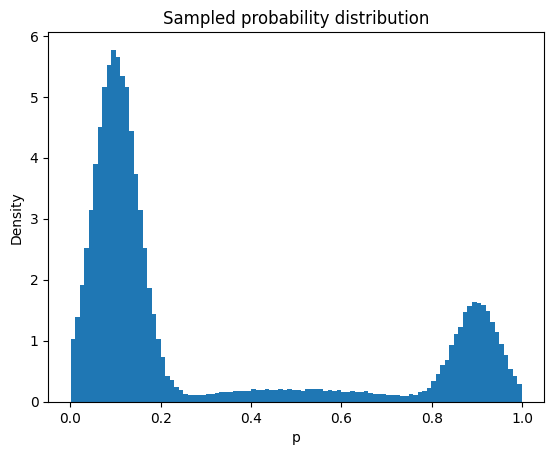

In [32]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import truncnorm

n = 100000

def sample_p(eps=1e-3):
    r = np.random.rand()

    if r < 0.70:
        mean, std = 0.1, 0.05
    elif r < 0.90:
        mean, std = 0.9, 0.05
    else:
        mean, std = 0.5, 0.20

    a = (eps - mean) / std
    b = (1 - eps - mean) / std

    return truncnorm.rvs(a, b, loc=mean, scale=std)

p = [sample_p() for _ in range(n)]

print(min(p), max(p))

plt.hist(p, bins=100, density=True)
plt.xlabel("p")
plt.ylabel("Density")
plt.title("Sampled probability distribution")
plt.show()

In [5]:
import pandas as pd
from pathlib import Path

raw_mapping_path = Path('../../datasets/WDN/full_set_4_raw.csv')
mapping_path = Path('../../datasets/WDN/full_set_4.csv')

df = pd.read_csv(raw_mapping_path)
df = df.drop(columns=['repetition'])
df['filename'] = ('run_' + df['filename'].str.replace(r'_\d+(?=\.csv$)', '', regex=True))
df = df.drop_duplicates()
df.to_csv(mapping_path, index=False)


In [ ]:
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
from tqdm import tqdm

mapping = pd.read_csv('../../datasets/WDN/full_set_3_test_df.csv')
dataset_dir = Path('../../datasets/WDN/full_set_3')

for filename in tqdm(mapping['filename']):
    df = pd.read_csv(dataset_dir / filename)
    df.plot(x='ElapsedTime[s]')
    plt.legend()
    plt.savefig(f"../../datasets/WDN/full_set_3_test_figs/{Path(filename).stem}.jpg", dpi=200)
    plt.close()

100%|██████████| 200/200 [00:36<00:00,  5.43it/s]


In [ ]:
import sys 
from pathlib import Path 
sys.path.insert(0, str(Path.cwd().parent))
from trans_comb_task import TransCombTask

species = ["H⁺", "H₂O", "Ca²⁺", "CO₂ (g)", "CO₂ (aq)", "CO₃²⁻", "HCO₃⁻", "H₂CO₃", "CaCO₃"]
initial_fractions = [0, 0.8, 0.1, 0.1, 0, 0, 0, 0, 0]
masses = [1, 18, 40,   44,  44,   60,   61,   62,   100]
reactions = [
    [[[3, 1], [4, 1]], 0.005],
    [[[4], [3]], 0.01],
    [[[4, 1], [7]], 0.02],
    [[[7], [4, 1]], 0.2],
    [[[7], [0, 6]], 0.865],
    [[[0, 6], [7]], 0.12],
    [[[6], [0, 5]], 0.03],
    [[[0, 5], [6]], 0.3],
    [[[8], [2, 5]], 0.002],
    [[[2, 5], [8]], 0.015],
]
reaction_dict = [
    {'indices': r[0], 'p': r[1]}
    for r in reactions 
]
task = TransCombTask(filename="water_network.jpg", species=species, masses=masses, fractions=initial_fractions, reactions=reaction_dict)
task.plot("../../results/WDN", large=True, dpi=300, title=False)

In [ ]:


import sys 
from pathlib import Path 
sys.path.insert(0, str(Path.cwd().parent))
from trans_comb_task import TransCombTask

species = list("ABC")
initial_fractions = [1/3, 1/3, 1/3]
masses = [1, 1, 2]
reactions = [
    [[[0], [1]], 0.2],
    [[[2], [0, 1]], 0.15],
    [[[0, 1], [2]], 0.05],
    [[[1, 2], [0, 2]], 0.03],
]
reaction_dict = [
    {'indices': r[0], 'p': r[1]}
    for r in reactions 
]
task = TransCombTask(filename="simple_example_network.jpg", species=species, masses=masses, fractions=initial_fractions, reactions=reaction_dict)
task.plot("../../results/WDN", dpi=300, title=False)

Starting prediction
Prediction took 0.622s
Starting prediction
Prediction took 0.606s


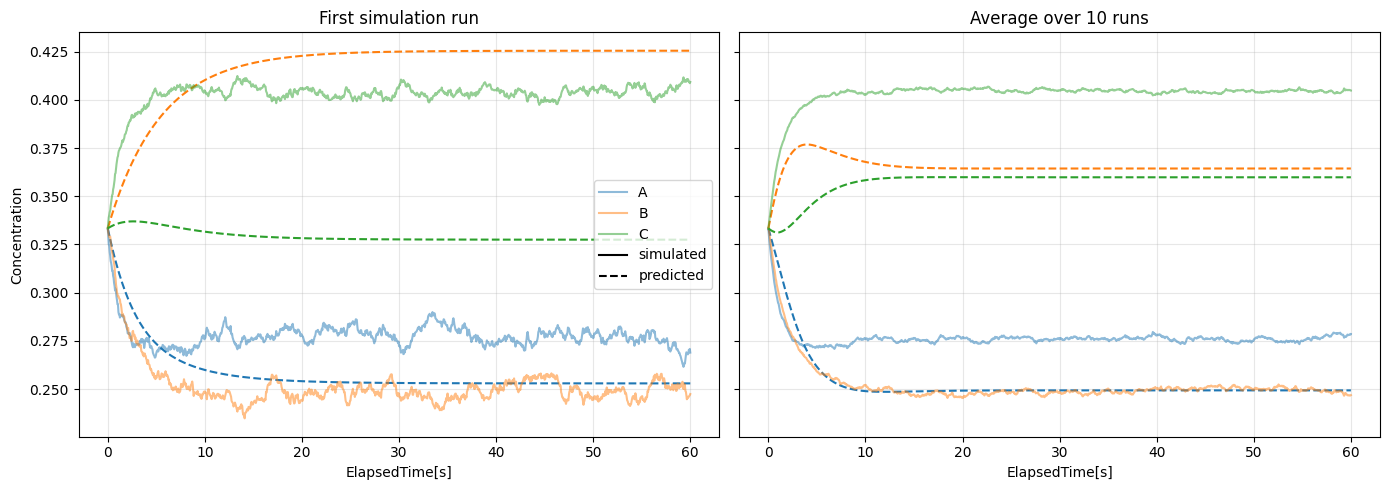

In [25]:
# test reaction network with all 4 reactions
# left: single run, prediction with model 3
# right: 10 runs averaged, prediction with model 4

import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from resample_counts import resample_counts
from pathlib import Path 
import sys
sys.path.insert(0, str(Path.cwd().parent))
from reaction_gnn import predict_trajectory, load_model 
from matplotlib.lines import Line2D
import numpy as np

species = list("ABC")
initial_fractions = [1/3, 1/3, 1/3]
masses = [1, 1, 2]
reactions = [
    [[[0], [1]], 0.2],
    [[[2], [1, 0]], 0.15],
    [[[1, 0], [2]], 0.05],
    [[[2, 1], [0, 2]], 0.03],
]

run_path = Path("../../datasets/WDN/small_example_averaged/run_0000.csv")
avg_path = Path("../../results/WDN/small_example_averaged_df.csv")

run_df = resample_counts(pd.read_csv(run_path))
avg_df = resample_counts(pd.read_csv(avg_path))

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharex=True, sharey=True)

for ax, df, title, first in zip(
    axes,
    [run_df, avg_df],
    ["First simulation run", "Average over 10 runs"],
    [True, False]
):
    set_name = "full_set_3" if first else "full_set_4"
    model_path = "../../results/WDN/" + set_name + ".pt"
    model = load_model(set_name)
    trajectory = predict_trajectory(model=model, initial_species_values=initial_fractions, masses=masses, reactions=reactions, steps=int(60/0.05), dt=0.05, device="cpu")
    trajectory = np.array(trajectory)

    for column in df.columns[1:]:
        i = species.index(column)
        color = f"C{i}"
        ax.plot(trajectory[:, 0], df[column], label=column, alpha=0.5, linestyle="-", color=color)
        ax.plot(trajectory[:, 0], trajectory[:, i + 1], linestyle="--", color=color)

    ax.set_title(title)
    ax.set_xlabel(df.columns[0])
    ax.set_ylabel("Concentration" if first else "")
    ax.grid(True, alpha=0.3)

handles, labels = axes[0].get_legend_handles_labels()
handles += [
    Line2D([0], [0], color='black', linestyle='-', label='simulated'),
    Line2D([0], [0], color='black', linestyle='--', label='predicted')
]
axes[0].legend(handles=handles)
fig.tight_layout()
plt.show()

Starting prediction
Prediction took 0.657s
Starting prediction
Prediction took 0.608s


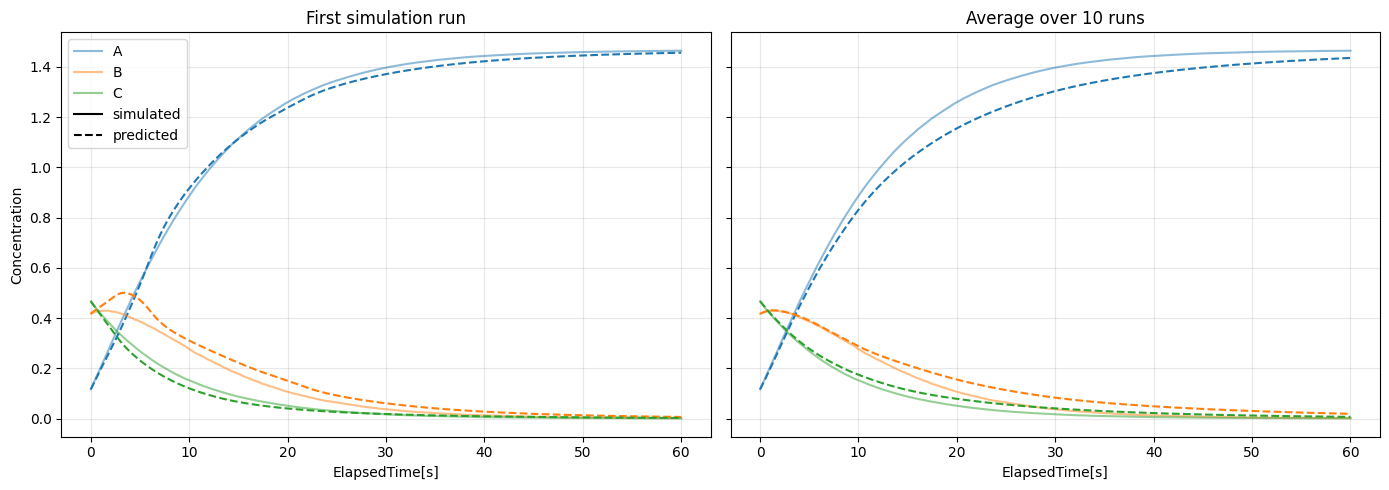

In [28]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from resample_counts import resample_counts
from pathlib import Path 
import sys
sys.path.insert(0, str(Path.cwd().parent))
from reaction_gnn import predict_trajectory, load_model 
from matplotlib.lines import Line2D
import numpy as np

species = list("ABC")
initial_fractions = [0.116, 0.417, 0.467]
masses = [9, 9, 18]
reactions = [
    [[[1], [0]], 0.1862],
    [[[2], [1, 1]], 0.106]
]

run_path = Path("../../datasets/WDN/full_set_4/run_18080.csv")
avg_path = Path("../../datasets/WDN/full_set_4/run_18080.csv")

run_df = resample_counts(pd.read_csv(run_path))
avg_df = resample_counts(pd.read_csv(avg_path))

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharex=True, sharey=True)

for ax, df, title, first in zip(
    axes,
    [run_df, avg_df],
    ["First simulation run", "Average over 10 runs"],
    [True, False]
):
    set_name = "full_set_4_5_epochs" if first else "full_set_4"
    model_path = "../../results/WDN/" + set_name + ".pt"
    model = load_model(set_name)
    trajectory = predict_trajectory(model=model, initial_species_values=initial_fractions, masses=masses, reactions=reactions, steps=int(60/0.05), dt=0.05, device="cpu")
    trajectory = np.array(trajectory)

    for column in df.columns[1:]:
        i = species.index(column)
        color = f"C{i}"
        ax.plot(trajectory[:, 0], df[column], label=column, alpha=0.5, linestyle="-", color=color)
        ax.plot(trajectory[:, 0], trajectory[:, i + 1], linestyle="--", color=color)

    ax.set_title(title)
    ax.set_xlabel(df.columns[0])
    ax.set_ylabel("Concentration" if first else "")
    ax.grid(True, alpha=0.3)

handles, labels = axes[0].get_legend_handles_labels()
handles += [
    Line2D([0], [0], color='black', linestyle='-', label='simulated'),
    Line2D([0], [0], color='black', linestyle='--', label='predicted')
]
axes[0].legend(handles=handles)
fig.tight_layout()
plt.show()